In [11]:
import os
# লাইব্রেরিগুলো ইমপোর্ট করার আগেই এটি সেট করে দিন
os.environ['OMP_NUM_THREADS'] = '1'
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
import pandas as pd
import numpy as np
import plotly.express as px
%matplotlib inline

In [2]:
X,y=make_blobs(n_samples=3000,centers=3,n_features=3,cluster_std=1.0)

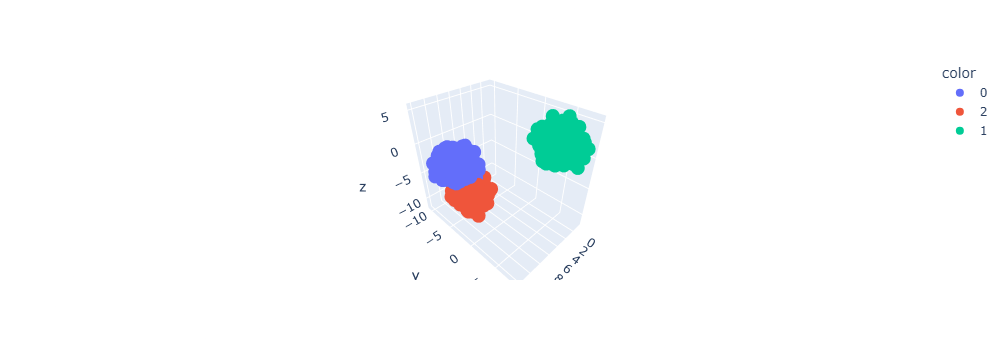

In [3]:
fig = px.scatter_3d(
    x=X[:,0],
    y=X[:,1],
    z=X[:,2],
    color=y.astype(str)   # color আলাদা করার জন্য
)

fig.show()

In [4]:
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()

In [5]:
from sklearn.model_selection import train_test_split

In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.33, random_state=42)

In [7]:
X_train_scaled=scaler.fit_transform(X_train)
X_test_scaled=scaler.transform(X_test)

In [8]:
from sklearn.cluster import KMeans

In [9]:

wcss=[]
for k in range(1,11):
    kmeans=KMeans(n_clusters=k,init="k-means++")
    kmeans.fit(X_train_scaled)
    wcss.append(kmeans.inertia_)

In [10]:
wcss

[6030.000000000013,
 888.3350967828593,
 354.3297263357613,
 311.0227977176406,
 276.11985866775916,
 264.47656085972443,
 225.66680747065905,
 214.14522146273958,
 199.81010141084312,
 189.95483668018292]

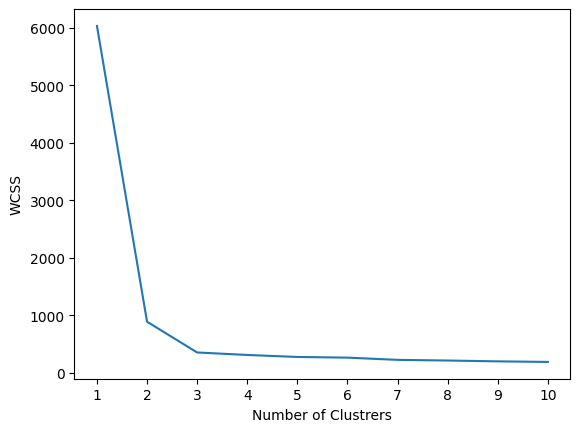

In [12]:
## plot elbow curve
plt.plot(range(1,11),wcss)
plt.xticks(range(1,11))
plt.xlabel("Number of Clustrers")
plt.ylabel("WCSS")
plt.show()

- kmeans.fit(X_train_scaled): এই লাইনের মাধ্যমে মডেলটি আপনার ট্রেইন ডেটার ভেতরে থাকা প্যাটার্নগুলো দেখে ক্লাস্টার সেন্টার বা সেন্ট্রয়েড ($centroids$) খুঁজে বের করে। অর্থাৎ, মডেলটি শিখছে কোথায় ক্লাস্টারগুলো হওয়া উচিত।
- y_pred = kmeans.predict(X_train_scaled): এই লাইনের মাধ্যমে আপনি মডেলকে বলছেন— "তুমি যে সেন্ট্রয়েডগুলো শিখলে, তার উপর ভিত্তি করে এখন বলো যে ট্রেইন ডেটার প্রতিটি পয়েন্ট কোন ক্লাস্টারে পড়েছে।" অর্থাৎ, ট্রেইন ডেটার ক্লাস্টার লেবেলগুলো পাওয়ার জন্য এখানে পুনরায় X_train_scaled দেওয়া হয়েছে।

In [23]:
k = 2  # elbow থেকে determine করা
kmeans = KMeans(n_clusters=k, init='k-means++', random_state=42)
# ১. ট্রেইন ডেটা দিয়ে মডেল ফিট করা
kmeans.fit(X_train_scaled)

KMeans(n_clusters=2, random_state=42)

In [24]:
# ২. ট্রেইন ডেটার ক্লাস্টার দেখা (ঐচ্ছিক)
y_train_pred = kmeans.predict(X_train_scaled)

In [25]:
# ৩. টেস্ট ডেটার ক্লাস্টার প্রিডিক্ট করা
# লক্ষ্য করুন: এখানে কিন্তু kmeans.fit(X_test_scaled) করা যাবে না!
y_test_pred = kmeans.predict(X_test_scaled)

In [30]:
y_test_pred

array([0, 1, 1, 1, 0, 1, 1, 1, 1, 1, 0, 1, 1, 0, 1, 1, 0, 0, 1, 1, 1, 1,
       1, 0, 1, 0, 0, 1, 1, 1, 1, 0, 0, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1,
       0, 0, 1, 1, 1, 1, 0, 0, 1, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1,
       1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1,
       0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 0, 1, 0, 1, 0, 0, 0, 0, 1, 0,
       1, 0, 1, 1, 1, 1, 1, 1, 1, 0, 0, 1, 0, 1, 0, 1, 0, 0, 1, 1, 0, 0,
       0, 0, 1, 1, 1, 0, 1, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 0,
       1, 1, 1, 0, 1, 1, 1, 0, 1, 1, 0, 1, 0, 0, 1, 0, 1, 1, 1, 1, 1, 0,
       1, 1, 1, 0, 1, 0, 1, 1, 1, 0, 0, 0, 0, 1, 0, 1, 0, 0, 1, 0, 1, 1,
       1, 0, 1, 1, 1, 0, 0, 1, 1, 1, 1, 1, 0, 1, 0, 0, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 0, 1, 1, 1, 0, 0, 1, 1, 0, 1, 0, 1, 0, 0, 0, 0, 1,
       1, 1, 1, 0, 1, 1, 1, 0, 0, 0, 0, 1, 1, 1, 1, 1, 0, 0, 1, 0, 1, 0,
       1, 1, 0, 1, 1, 1, 1, 0, 0, 1, 1, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 1,
       0, 1, 0, 1, 1, 1, 1, 1, 0, 1, 0, 1, 1, 0, 0,

### আনসুপারভাইজড লার্নিং বা $K-Means$ ক্লাস্টারিংয়ের ক্ষেত্রে "মডেল কতটা ভালো" সেটা বোঝা সুপারভাইজড লার্নিংয়ের (যেমন রিগ্রেশন বা ক্লাসিফিকেশন) মতো অতটা সহজ নয়, কারণ এখানে কোনো সঠিক উত্তর বা y_true লেবেল থাকে না।তবে আপনার মডেলের পারফরম্যান্স যাচাই করার কিছু নির্দিষ্ট পদ্ধতি আছে:
 - Inertia (WCSS)
 - Silhouette Score

In [26]:
## silhoutte score
from sklearn.metrics import silhouette_score

In [27]:
silhouette_coefficients=[]
for k in range(2,11):
    kmeans=KMeans(n_clusters=k,init="k-means++")
    kmeans.fit(X_train_scaled)
    score=silhouette_score(X_train_scaled,kmeans.labels_)
    silhouette_coefficients.append(score)

In [28]:
silhouette_coefficients

[np.float64(0.7663252545321374),
 np.float64(0.6664046090009974),
 np.float64(0.5425295126282798),
 np.float64(0.37169687220033487),
 np.float64(0.2763872068717697),
 np.float64(0.2678594224331208),
 np.float64(0.2493999043617418),
 np.float64(0.24489871764470528),
 np.float64(0.23062386666436782)]

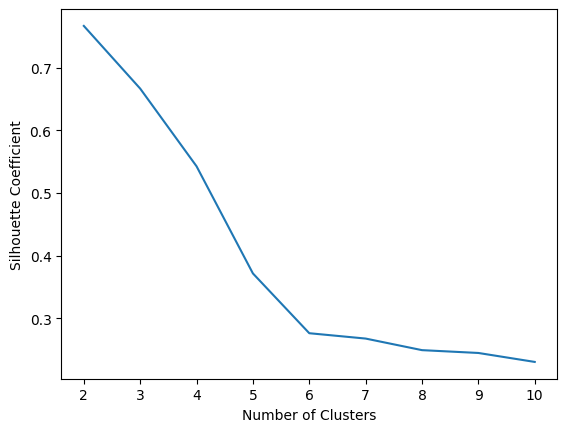

In [29]:
plt.plot(range(2,11), silhouette_coefficients)   
plt.xticks(range(2,11))
plt.xlabel("Number of Clusters")
plt.ylabel("Silhouette Coefficient")
plt.show()

### Silhouette Onujai Jar jonno man sobtheke beshi, seta k er jonno best. So, Best k will be 2